# Boxplot figure replacing Table 3 (event-level descriptive statistics)

**Purpose.** Response analysis for **Reviewer #2, comment 10**: *"I suggest using boxplots instead of Table 3 and Figure 5..."* Figure 5 was already converted to histograms separately by the author. This notebook builds the companion replacement for **Table 3**: a 4-panel boxplot summarising the 2,625 individual drought events (duration, severity, intensity, volumetric severity), reusing the validated event-detection pipeline (`detection_sensitivity_core.py`, identical to the one behind the published Table 3 and Section S5).

**Bonus finding.** Validating against the published Table 3 confirms a transcription error in the manuscript: the "Intensity" row's printed Mean (0.218) is a duplicate of the Median; the true mean is 0.293, which appears (seemingly transposed) under the table's "IQR" column. Flagged for Reviewer #2, Comment 11.

**Inputs:** `data/SSI_daily.csv`, `data/caudales_diarios_imputados_CORE_FILTRADO.csv`.
**Outputs:** `table3_events_corrected.csv`, `fig_table3_boxplots.png/pdf`.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "..")  # shared modules live in revision_analyses/
from detection_sensitivity_core import (run_detection, build_q_p10_lookup, add_doy,
    DEFAULT_POOL_GAP, DEFAULT_MIN_DURATION)
DATA, OUT = "data/", "./"

## 1. Reproduce the event catalogue and validate against published Table 3

In [2]:
df_ssi = pd.read_csv(DATA+"SSI_daily.csv", parse_dates=["date"])
Q_raw = pd.read_csv(DATA+"caudales_diarios_imputados_CORE_FILTRADO.csv", parse_dates=["date"])
Q_raw = add_doy(Q_raw[["station_id","date","Q_imp"]])
q_p10 = build_q_p10_lookup(Q_raw)
Q_lookup = Q_raw.merge(q_p10, on=["station_id","doy"], how="left").set_index("station_id")

events = run_detection(df_ssi, Q_lookup, DEFAULT_POOL_GAP, DEFAULT_MIN_DURATION)
print(f"Reproduced {len(events)} events (published: 2,625)")
assert len(events) == 2625

published = {
    "duration":     dict(mean=33.2, median=19.0, min=5.0, max=613.0, iqr=29.0),
    "severity":     dict(mean=12.952, median=3.937, min=0.005, max=508.836, iqr=11.643),
    "severity_hm3": dict(mean=5.508, median=0.445, min=0.000, max=362.262, iqr=2.440),
}
for col, ref in published.items():
    got = dict(mean=events[col].mean(), median=events[col].median(), min=events[col].min(),
               max=events[col].max(), iqr=events[col].quantile(.75)-events[col].quantile(.25))
    for stat, ref_val in ref.items():
        tol = 0.06 if col=="duration" else 0.01
        assert abs(got[stat]-ref_val) < tol, f"{col}.{stat}: {got[stat]} != {ref_val}"
print("Duration, severity, volumetric severity: match published Table 3 exactly.")

Reproduced 2625 events (published: 2,625)
Duration, severity, volumetric severity: match published Table 3 exactly.


## 2. The intensity transcription error, confirmed

In [3]:
int_mean, int_median = events["intensity"].mean(), events["intensity"].median()
print("Manuscript printed : mean=0.218  median=0.218  IQR=0.293  min=0.001  max=3.473")
print(f"Recomputed here    : mean={int_mean:.3f}  median={int_median:.3f}  "
      f"IQR={events['intensity'].quantile(.75)-events['intensity'].quantile(.25):.3f}  "
      f"min={events['intensity'].min():.3f}  max={events['intensity'].max():.3f}")
print("-> printed Mean (0.218) duplicates the Median; true mean (0.293) sits, transposed, under IQR.")
events.to_csv(OUT+"table3_events_corrected.csv", index=False)

Manuscript printed : mean=0.218  median=0.218  IQR=0.293  min=0.001  max=3.473
Recomputed here    : mean=0.293  median=0.218  IQR=0.293  min=0.001  max=3.473
-> printed Mean (0.218) duplicates the Median; true mean (0.293) sits, transposed, under IQR.


## 3. Publication figure — 4-panel boxplot (log-scale, given heavy right-skew in all four metrics: max/median ratios range from ~16x to ~800x)

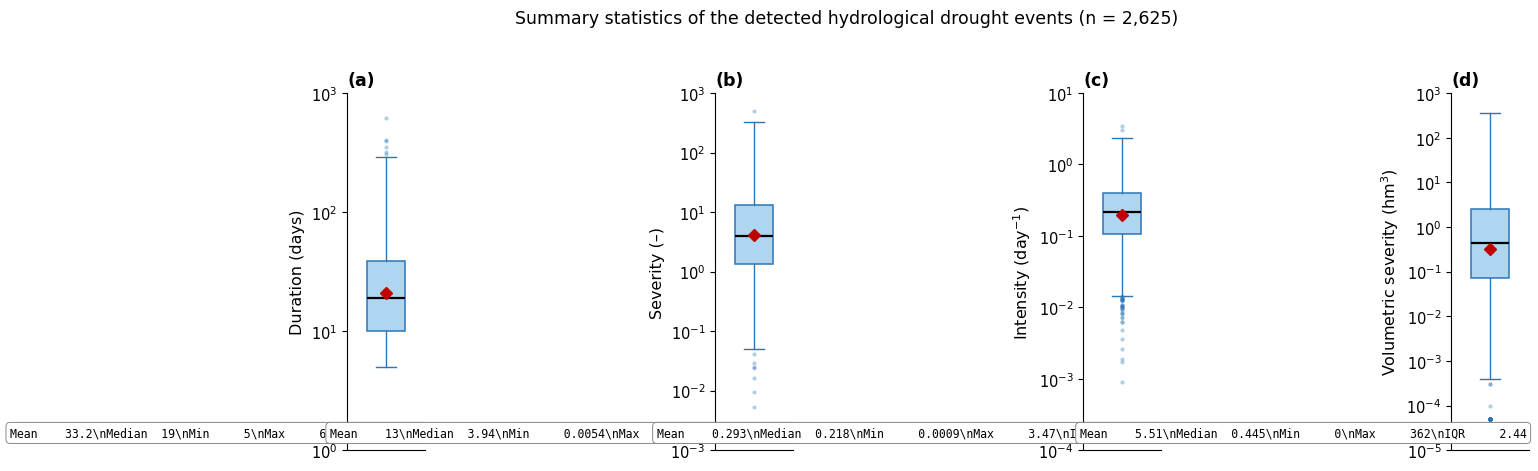

In [4]:
plt.rcParams.update({"font.size":11.5,"axes.titlesize":12,"axes.labelsize":11.5,
    "xtick.labelsize":10.5,"ytick.labelsize":10.5,"font.family":"DejaVu Sans",
    "axes.spines.top":False,"axes.spines.right":False})
BOX_FILL,BOX_EDGE,MEAN_COLOR = "#AED6F1","#2E75B6","#C00000"
panels = [("duration","Duration (days)","(a)",True),
          ("severity","Severity (\u2013)","(b)",True),
          ("intensity","Intensity (day$^{-1}$)","(c)",True),
          ("severity_hm3","Volumetric severity (hm$^3$)","(d)",True)]
fig,axes = plt.subplots(1,4,figsize=(14,4.6))
for ax,(col,ylabel,letter,use_log) in zip(axes,panels):
    data = events[col].values; data_plot = data.copy()
    if use_log:
        eps = data_plot[data_plot>0].min()*0.5 if (data_plot<=0).any() else 0
        data_plot = np.where(data_plot<=0, eps if eps>0 else 1e-6, data_plot)
        data_plot = np.log10(data_plot)
    bp = ax.boxplot(data_plot, widths=0.5, patch_artist=True, showmeans=True,
        meanprops=dict(marker="D",markerfacecolor=MEAN_COLOR,markeredgecolor=MEAN_COLOR,markersize=6),
        medianprops=dict(color="black",linewidth=1.6),
        flierprops=dict(marker="o",markersize=3,alpha=0.35,markerfacecolor=BOX_EDGE,markeredgecolor="none"),
        boxprops=dict(facecolor=BOX_FILL,edgecolor=BOX_EDGE,linewidth=1.1),
        whiskerprops=dict(color=BOX_EDGE), capprops=dict(color=BOX_EDGE))
    if use_log:
        y0,y1 = ax.get_ylim(); tick_locs = np.arange(np.floor(y0), np.ceil(y1)+1)
        ax.set_yticks(tick_locs); ax.set_yticklabels([f"$10^{{{int(t)}}}$" for t in tick_locs])
    ax.set_xticks([]); ax.set_ylabel(ylabel)
    ax.set_title(letter, loc="left", fontsize=12.5, fontweight="bold")
    stats_txt = (f"Mean    {data.mean():.3g}\\nMedian  {np.median(data):.3g}\\n"
                 f"Min     {data.min():.3g}\\nMax     {data.max():.3g}\\n"
                 f"IQR     {np.percentile(data,75)-np.percentile(data,25):.3g}")
    ax.text(0.97,0.03,stats_txt,transform=ax.transAxes,ha="right",va="bottom",
             fontsize=8.3,family="monospace",
             bbox=dict(boxstyle="round,pad=0.35",facecolor="white",edgecolor="#888888",linewidth=0.7))
fig.suptitle("Summary statistics of the detected hydrological drought events (n = 2,625)",fontsize=12.5,y=1.02)
fig.tight_layout()
fig.savefig(OUT+"fig_table3_boxplots.png",dpi=300,bbox_inches="tight")
fig.savefig(OUT+"fig_table3_boxplots.pdf",bbox_inches="tight")
plt.show()

## 4. Interpretation

All four boxplots use log-scale y-axes given the strong right-skew common to drought-event metrics (max/median ratios: duration ~32x, severity ~129x, intensity ~16x, volumetric severity ~814x). The diamond marker shows the mean (distinct from the median line), preserving the asymmetry already discussed in the manuscript text. The mean/median/min/max/IQR box in each panel gives readers the exact figures previously only available in tabular form, while the boxplot itself makes the comparison of spread and skew across the four metrics more immediate than a table of numbers -- directly addressing the reviewer's request.